# B4 Setup — Propensity and Overlap Diagnostics

**This notebook is diagnostic only. It does not estimate any causal effect
and does not run AIPW.** It fits a propensity model `P(private | W)` for
the private-vs-public exposure contrast, and reports the covariate-balance
and overlap diagnostics that must be checked *before* any adjusted causal
estimate is trusted. Nothing here should be read as an effect estimate.

**Not run here.** Written but not executed, per instruction — no commands
run, no model fit, no diagnostics computed while authoring this notebook.
Run it locally in VS Code.

**Population and exposure.** Primary causal contrast is private (1) vs
public (0) institutional deliveries. `other`-sector records are excluded
from this notebook entirely (consistent with every prior B1/B2/B3 rule in
this project) — not just from a contrast, but from the analytic sample
here, since a propensity model for a binary exposure needs a binary
population.

**Why this fits on the full v2 sample, not the B2/B3 locked test split.**
B2's train/test split exists to evaluate the *predictive* XGBoost model
out-of-sample. The propensity model here is a separate model serving a
different purpose (causal adjustment, not outcome prediction), and doesn't
inherit that split — fitting it on the full private/public analytic sample
is standard practice for overlap diagnostics. Cross-fitting (splitting
folds to avoid the propensity and outcome models overfitting each other) is
an AIPW-estimation-stage concern and is deliberately deferred to B4 itself,
not built here.

## 1. Imports, paths, constants

In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TRIM_LOWER = 0.05    # pre-specified trimming sensitivity thresholds
TRIM_UPPER = 0.95
CLIP_EPS = 1e-6      # numerical clipping bound so propensities are strictly in (0, 1)
SMD_FLAG_THRESHOLD = 0.1

RUN_ML_SENSITIVITY_MODEL = False  # optional flexible propensity model; off by default, see Section 6a

## 2. Load `df_model_v2` (read-only), restrict to public/private, assert integrity

In [17]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. Stop and investigate."
)

n_other = (df["facility_type"] == "other").sum()
analytic = df[df["facility_type"].isin(["public", "private"])].copy()

# --- Assertion: only public/private records included ---
assert set(analytic["facility_type"].unique()) <= {"public", "private"}, \
    "Non public/private facility type leaked into the analytic sample."
print(f"Excluded 'other' facility records: {n_other}")
print(f"Analytic sample (public + private only): {len(analytic)} of {n_loaded}")

analytic["exposure"] = (analytic["facility_type"] == "private").astype(int)

# --- Assertion: no missing exposure ---
assert analytic["exposure"].isna().sum() == 0, "Missing exposure values found."
assert analytic["facility_type"].isna().sum() == 0, "Missing facility_type values found."
print("No missing exposure values.")
print(analytic["exposure"].value_counts().rename({0: "public", 1: "private"}))

Excluded 'other' facility records: 517
Analytic sample (public + private only): 200794 of 201311
No missing exposure values.
exposure
public     150299
private     50495
Name: count, dtype: int64


## 3. Confounder set — pre-exposure, DAG-approved only

**Included in the primary adjustment set (8):** `birth_order`, `twin_order`,
`wealth_index`, `education_years`, `residence`, `religion`, `social_group`,
`state`. All are baseline/pre-exposure characteristics plausibly affecting
both facility choice and C-section risk, and none are downstream of
facility choice.

**`maternal_age` removed from the primary set — documented limitation.**
`maternal_age` is sourced from `v012`, which DHS records as **age at
interview**, not age at the analyzed birth. For a birth several years
before the survey, current age can overstate age-at-birth by however many
years have passed — i.e. it is not verified pre-exposure for any birth that
isn't very recent relative to the interview date. A precise age-at-birth
would require the child's date of birth and the mother's date of birth
(DHS `b3`/`v011`, in century-month-code form) to compute directly; neither
is currently a column in `df_model_v2`, so a general age-at-index-birth
variable is **not safely derivable from the existing v2 schema** for the
full public/private analytic sample. The one exception: for `birth_order ==
1` records specifically, `age_at_first_birth` (`v212`) *is* exactly the age
at that birth by construction — so a first-birth-restricted sensitivity
propensity model using `age_at_first_birth` in place of `maternal_age`
remains a documented option, but is not built into the primary model here
since it would only cover a subset of the analytic sample. Pulling `b3`/
`v011` from the raw NFHS-5 file (same access constraint as `v106`/`v131`
earlier in this project) would resolve this properly if raw access becomes
available.

**Explicitly excluded from the primary set, with reasons (not silently
omitted):**
- All ANC/service-utilization variables (`anc_visits`, `anc_doctor`,
  `first_anc_timing`, the `counselled_*` and `m42*`-derived variables,
  `told_about_pregnancy_complications`) — health-service mediators,
  plausibly occurring at or after facility choice, per the frozen
  protocol's own domain reclassification (Step 2).
- `facility_type` / `delivery_place_code` — the exposure itself, not a
  confounder.
- `bmi` and `health_insurance` — sensitivity-only. Neither variable's
  timing relative to the analyzed birth has been verified as clearly
  pre-exposure.
- `convulsions_during_pregnancy` / `swelling_during_pregnancy` (`s434`/
  `s435`) — sensitivity-only: Step 2's audit found their missingness is
  systematic (linked to ANC attendance, wealth, and the outcome itself).
- `total_children_ever_born` — excluded: unresolved timing concern
  (survey-date snapshot) flagged in the Step 2 variable dictionary.
- `preceding_birth_interval`, `age_at_first_birth`, and `district` —
  optional sensitivity variables (the first two carry an unresolved DHS
  special-code `TODO` from Step 2; `district` is a finer-grained geographic
  control than the primary `state` adjustment).
- IDs and other survey-design fields (`respondent_id`, `cluster_number`,
  `sample_weight*`, `sample_stratum_*`, etc.) — not confounders.
- `risk_stratum_primary` / `risk_stratum_refined_sensitivity` / `first_birth`
  — v2-derived stratifiers, not baseline confounders; excluded as
  predictors here per instruction.

In [18]:
numeric_confounders = ["birth_order", "wealth_index", "education_years"]
categorical_confounders = ["residence", "religion", "social_group", "twin_order", "state"]
confounder_cols = numeric_confounders + categorical_confounders

mediator_and_forbidden = {
    "anc_visits", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "first_anc_timing", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "facility_type", "delivery_place_code",
    "bmi", "health_insurance",  # sensitivity-only: pre-exposure timing not verified
    "maternal_age",  # sensitivity-only: v012 is age at interview, not verified age at index birth
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "district",
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023",
    "csection",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}

# --- Assertion: no mediator/post-exposure/forbidden variable in the confounder set ---
overlap = mediator_and_forbidden.intersection(set(confounder_cols))
assert not overlap, f"Forbidden/mediator variable found in confounder set: {overlap}"
print(f"Confounder set: {len(confounder_cols)} variables. No mediator/forbidden overlap confirmed.")

Confounder set: 8 variables. No mediator/forbidden overlap confirmed.


## 4. Fit the propensity model — survey-weighted Logistic Regression, no outcome tuning

The primary propensity model is fit **using `sample_weight_normalized` as
the estimator's `sample_weight`**, so the nuisance model itself reflects the
survey design rather than treating the analytic sample as a simple random
sample. No class rebalancing and no hyperparameter search: propensity
scores must reflect the actual (survey-weighted) conditional probability of
private-sector delivery, and there is no legitimate outcome-free scoring
target to tune against without risking a "don't peek at the outcome"
violation. Missing confounder values (`social_group` has some missingness
in this set) are imputed with the same missing-indicator/explicit-category
approach used throughout this project — no rows are dropped.

In [19]:
W = analytic[confounder_cols].copy()
for col in categorical_confounders:
    W[col] = W[col].astype("string").fillna("Missing").astype(str)

n_before_preprocessing = len(W)

propensity_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), numeric_confounders),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_confounders),
])

propensity_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
propensity_pipeline = Pipeline([("pre", propensity_preprocessor), ("clf", propensity_model)])

exposure = analytic["exposure"].to_numpy()
propensity_sample_weight = analytic["sample_weight_normalized"].to_numpy()

# Survey-weighted fit: sample_weight is passed through to the LogisticRegression
# step via the "clf__" pipeline prefix.
propensity_pipeline.fit(W, exposure, clf__sample_weight=propensity_sample_weight)

propensity_raw = propensity_pipeline.predict_proba(W)[:, 1]

# --- Assertion: no silent row loss from imputation/preprocessing ---
assert len(propensity_raw) == n_before_preprocessing == len(analytic), \
    "Row count changed while fitting/predicting the propensity model."
print(f"Propensity model fit on {len(analytic)} records (survey-weighted). No row loss.")

Propensity model fit on 200794 records (survey-weighted). No row loss.


### 4a. Optional flexible ML sensitivity propensity model (off by default)

Set `RUN_ML_SENSITIVITY_MODEL = True` above to additionally fit a
gradient-boosted propensity model on the same confounder set, purely as a
sensitivity comparison against the transparent Logistic Regression model.
This is exploratory and not part of the primary diagnostic pipeline. Note:
unlike the primary model above, this sensitivity model does **not**
currently pass `sample_weight_normalized` to the fit — if it's enabled and
compared directly against the primary model's distribution, that asymmetry
should be kept in mind.

In [20]:
if RUN_ML_SENSITIVITY_MODEL:
    from xgboost import XGBClassifier

    tree_propensity_preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_confounders),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_confounders),
    ])
    ml_propensity_pipeline = Pipeline([
        ("pre", tree_propensity_preprocessor),
        ("clf", XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
            n_estimators=200, max_depth=4, learning_rate=0.05,
        )),
    ])
    ml_propensity_pipeline.fit(W, exposure)
    propensity_ml_raw = ml_propensity_pipeline.predict_proba(W)[:, 1]
    print("ML sensitivity propensity model fit. Compare its distribution against the LR model before relying on either for B4.")
else:
    propensity_ml_raw = None
    print("RUN_ML_SENSITIVITY_MODEL is False -- skipping the optional ML sensitivity model.")

RUN_ML_SENSITIVITY_MODEL is False -- skipping the optional ML sensitivity model.


## 5. Clip propensities and assemble the row-level diagnostics frame

In [21]:
propensity_clipped = np.clip(propensity_raw, CLIP_EPS, 1 - CLIP_EPS)

# --- Assertion: propensity strictly between 0 and 1 after clipping ---
assert (propensity_clipped > 0).all() and (propensity_clipped < 1).all(), \
    "Clipped propensity values are not strictly within (0, 1)."
n_clipped = int(((propensity_raw <= CLIP_EPS) | (propensity_raw >= 1 - CLIP_EPS)).sum())
print(f"Records requiring clipping: {n_clipped} of {len(propensity_raw)}")

diagnostics = pd.DataFrame({
    "respondent_id": analytic["respondent_id"].to_numpy(),
    "facility_type": analytic["facility_type"].to_numpy(),
    "exposure": exposure,
    "propensity_raw": propensity_raw,
    "propensity_clipped": propensity_clipped,
    "sample_weight_normalized": analytic["sample_weight_normalized"].to_numpy(),
})
if propensity_ml_raw is not None:
    diagnostics["propensity_ml_sensitivity"] = propensity_ml_raw

print(f"Diagnostics frame: {diagnostics.shape}")

Records requiring clipping: 0 of 200794
Diagnostics frame: (200794, 6)


## 6. Stabilized IPW and combined weight — formula documented explicitly

Stabilized IPW: for private (exposure=1) records,
`sw = P(private) / propensity`; for public (exposure=0) records,
`sw = (1 - P(private)) / (1 - propensity)`, where `P(private)` is the
**survey-weighted marginal prevalence** of private-sector delivery in this
sample (not the unweighted sample proportion). This is now consistent
end-to-end: the propensity model itself is fit survey-weighted (Section 4),
and the marginal used to stabilize it is also survey-weighted.

**Combined weight, stated exactly once and used consistently below:**
`combined_weight = sample_weight_normalized * stabilized_ipw`.
This combined weight is used for the "after weighting" balance diagnostics
and the effective-sample-size table. It is **not** used to estimate any
effect in this notebook.

In [22]:
survey_weighted_marginal_private = np.average(exposure, weights=diagnostics["sample_weight_normalized"])
print(f"Survey-weighted marginal P(private): {survey_weighted_marginal_private:.4f}")

stabilized_ipw = np.where(
    diagnostics["exposure"] == 1,
    survey_weighted_marginal_private / diagnostics["propensity_clipped"],
    (1 - survey_weighted_marginal_private) / (1 - diagnostics["propensity_clipped"]),
)
diagnostics["stabilized_ipw"] = stabilized_ipw
diagnostics["combined_weight"] = diagnostics["sample_weight_normalized"] * diagnostics["stabilized_ipw"]

print("Stabilized IPW summary:")
print(diagnostics["stabilized_ipw"].describe())

Survey-weighted marginal P(private): 0.3011
Stabilized IPW summary:
count    200794.000000
mean          0.990799
std           0.671750
min           0.310162
25%           0.746157
50%           0.824299
75%           1.025491
max          52.994628
Name: stabilized_ipw, dtype: float64


## 7. Common support, extreme-propensity counts, and trimming sensitivity

In [23]:
private_prop = diagnostics.loc[diagnostics["exposure"] == 1, "propensity_clipped"]
public_prop = diagnostics.loc[diagnostics["exposure"] == 0, "propensity_clipped"]

common_support_low = max(private_prop.min(), public_prop.min())
common_support_high = min(private_prop.max(), public_prop.max())

diagnostics["within_common_support"] = diagnostics["propensity_clipped"].between(
    common_support_low, common_support_high
)
diagnostics["extreme_propensity"] = (
    (diagnostics["propensity_clipped"] < TRIM_LOWER) | (diagnostics["propensity_clipped"] > TRIM_UPPER)
)

overlap_summary_rows = []
for label, mask in [("overall", pd.Series(True, index=diagnostics.index)),
                     ("private", diagnostics["exposure"] == 1),
                     ("public", diagnostics["exposure"] == 0)]:
    sub = diagnostics[mask]
    overlap_summary_rows.append({
        "group": label,
        "n": len(sub),
        "propensity_min": sub["propensity_clipped"].min(),
        "propensity_max": sub["propensity_clipped"].max(),
        "n_within_common_support": int(sub["within_common_support"].sum()),
        "pct_within_common_support": round(sub["within_common_support"].mean() * 100, 2),
        "n_extreme_lt_0.05_or_gt_0.95": int(sub["extreme_propensity"].sum()),
        "pct_extreme": round(sub["extreme_propensity"].mean() * 100, 2),
    })

overlap_summary = pd.DataFrame(overlap_summary_rows)
overlap_summary.attrs["common_support_range"] = (common_support_low, common_support_high)
overlap_summary.to_csv(TABLES_DIR / "b4_overlap_summary.csv", index=False)

print(f"Common support range: [{common_support_low:.4f}, {common_support_high:.4f}]")
overlap_summary

Common support range: [0.0057, 0.9159]


,group,n,propensity_min,propensity_max,n_within_common_support,pct_within_common_support,n_extreme_lt_0.05_or_gt_0.95,pct_extreme
0,overall,200794,0.004632,0.970922,200725,99.97,17446,8.69
1,private,50495,0.005683,0.970922,50454,99.92,477,0.94
2,public,150299,0.004632,0.915898,150271,99.98,16969,11.29


In [24]:
# Pre-specified trimming sensitivity (diagnostic only -- no effect estimated on the trimmed sample here)
trimmed = diagnostics[~diagnostics["extreme_propensity"]]
n_trimmed_out = len(diagnostics) - len(trimmed)
print(f"Records outside [{TRIM_LOWER}, {TRIM_UPPER}] propensity range: {n_trimmed_out} "
      f"({n_trimmed_out / len(diagnostics) * 100:.2f}% of the analytic sample)")
print("Trimmed-sample counts by arm:")
print(trimmed["exposure"].value_counts().rename({0: "public", 1: "private"}))

Records outside [0.05, 0.95] propensity range: 17446 (8.69% of the analytic sample)
Trimmed-sample counts by arm:
exposure
public     133330
private     50018
Name: count, dtype: int64


## 8. Effective sample size — overall and by treatment arm

`ESS = (sum(w))^2 / sum(w^2)` for each weight type, computed overall and
within each arm.

In [25]:
def effective_sample_size(weights):
    weights = np.asarray(weights)
    return (weights.sum() ** 2) / (weights ** 2).sum()

ess_rows = []
for label, mask in [("overall", pd.Series(True, index=diagnostics.index)),
                     ("private", diagnostics["exposure"] == 1),
                     ("public", diagnostics["exposure"] == 0)]:
    sub = diagnostics[mask]
    ess_rows.append({
        "group": label,
        "n_unweighted": len(sub),
        "ess_survey_weight_only": effective_sample_size(sub["sample_weight_normalized"]),
        "ess_stabilized_ipw_only": effective_sample_size(sub["stabilized_ipw"]),
        "ess_combined_weight": effective_sample_size(sub["combined_weight"]),
    })

ess_summary = pd.DataFrame(ess_rows)
ess_summary.to_csv(TABLES_DIR / "b4_ess_summary.csv", index=False)
ess_summary

,group,n_unweighted,ess_survey_weight_only,ess_stabilized_ipw_only,ess_combined_weight
0,overall,200794,104035.626625,137561.729837,79457.817152
1,private,50495,26373.592132,23613.627934,20205.097334
2,public,150299,79112.087678,134726.135249,60379.849484


## 9. Standardized mean differences — before and after weighting

Categorical confounders are expanded to one dummy per level (matching
standard covariate-balance reporting); SMD is scale-invariant so computing
it on original (not standardized) values is equivalent. "After" weighting
uses the **combined weight** (survey × stabilized IPW), consistent with
Section 6.

In [26]:
def weighted_mean_var(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.average(x, weights=w)
    var = np.average((x - mean) ** 2, weights=w)
    return mean, var


def smd(x1, w1, x0, w0):
    m1, v1 = weighted_mean_var(x1, w1)
    m0, v0 = weighted_mean_var(x0, w0)
    pooled_sd = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled_sd if pooled_sd > 0 else np.nan


# Build a balance-check frame: original confounder values (median-imputed for
# numeric, "Missing" category for categorical -- same treatment as the model),
# aligned to the diagnostics frame's row order.
balance_source = analytic[confounder_cols].copy()
for col in numeric_confounders:
    balance_source[col] = balance_source[col].fillna(balance_source[col].median())
for col in categorical_confounders:
    balance_source[col] = balance_source[col].astype("string").fillna("Missing").astype(str)

balance_dummies = pd.get_dummies(balance_source, columns=categorical_confounders, prefix=categorical_confounders)

exposure_mask = diagnostics["exposure"].to_numpy() == 1
unweighted_ones = np.ones(len(diagnostics))
combined_w = diagnostics["combined_weight"].to_numpy()

balance_rows = []
for col in balance_dummies.columns:
    values = balance_dummies[col].to_numpy(dtype=float)
    smd_before = smd(values[exposure_mask], unweighted_ones[exposure_mask],
                      values[~exposure_mask], unweighted_ones[~exposure_mask])
    smd_after = smd(values[exposure_mask], combined_w[exposure_mask],
                     values[~exposure_mask], combined_w[~exposure_mask])
    balance_rows.append({"covariate": col, "smd_before": smd_before, "smd_after": smd_after})

covariate_balance = pd.DataFrame(balance_rows)
covariate_balance["flag_after_weighting"] = covariate_balance["smd_after"].abs() > SMD_FLAG_THRESHOLD
covariate_balance = covariate_balance.sort_values("smd_before", key=np.abs, ascending=False)
covariate_balance.to_csv(TABLES_DIR / "b4_covariate_balance.csv", index=False)

n_flagged = covariate_balance["flag_after_weighting"].sum()
print(f"Covariates with |SMD| > {SMD_FLAG_THRESHOLD} after weighting: {n_flagged} of {len(covariate_balance)}")
covariate_balance

Covariates with |SMD| > 0.1 after weighting: 0 of 60


,covariate,smd_before,smd_after,flag_after_weighting
1,wealth_index,0.814069,-0.001607,False
2,education_years,0.600973,-0.027494,False
3,residence_1,0.386744,0.004047,False
4,residence_2,-0.386744,-0.004047,False
16,social_group_2,-0.368924,-0.043572,False
40,state_24,0.266411,-0.003770,False
39,state_23,-0.256238,-0.055221,False
18,social_group_4,0.243502,-0.006344,False
0,birth_order,-0.236529,0.020173,False
17,social_group_3,0.216915,0.008249,False


## 10. Figures — propensity overlap plot and Love plot

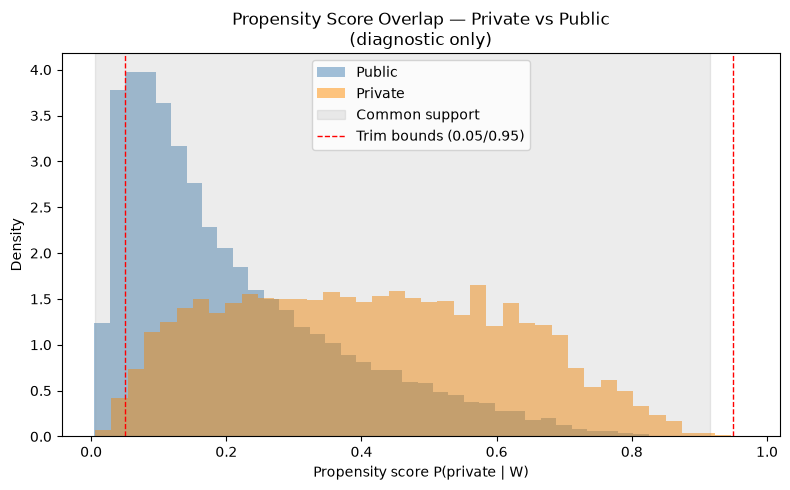

Saved: ..\..\outputs\figures\b4_propensity_overlap.png


In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(public_prop, bins=40, alpha=0.5, label="Public", density=True, color="steelblue")
ax.hist(private_prop, bins=40, alpha=0.5, label="Private", density=True, color="darkorange")
ax.axvspan(common_support_low, common_support_high, color="gray", alpha=0.15, label="Common support")
ax.axvline(TRIM_LOWER, color="red", linestyle="--", linewidth=1, label=f"Trim bounds ({TRIM_LOWER}/{TRIM_UPPER})")
ax.axvline(TRIM_UPPER, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Propensity score P(private | W)")
ax.set_ylabel("Density")
ax.set_title("Propensity Score Overlap — Private vs Public\n(diagnostic only)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b4_propensity_overlap.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b4_propensity_overlap.png")

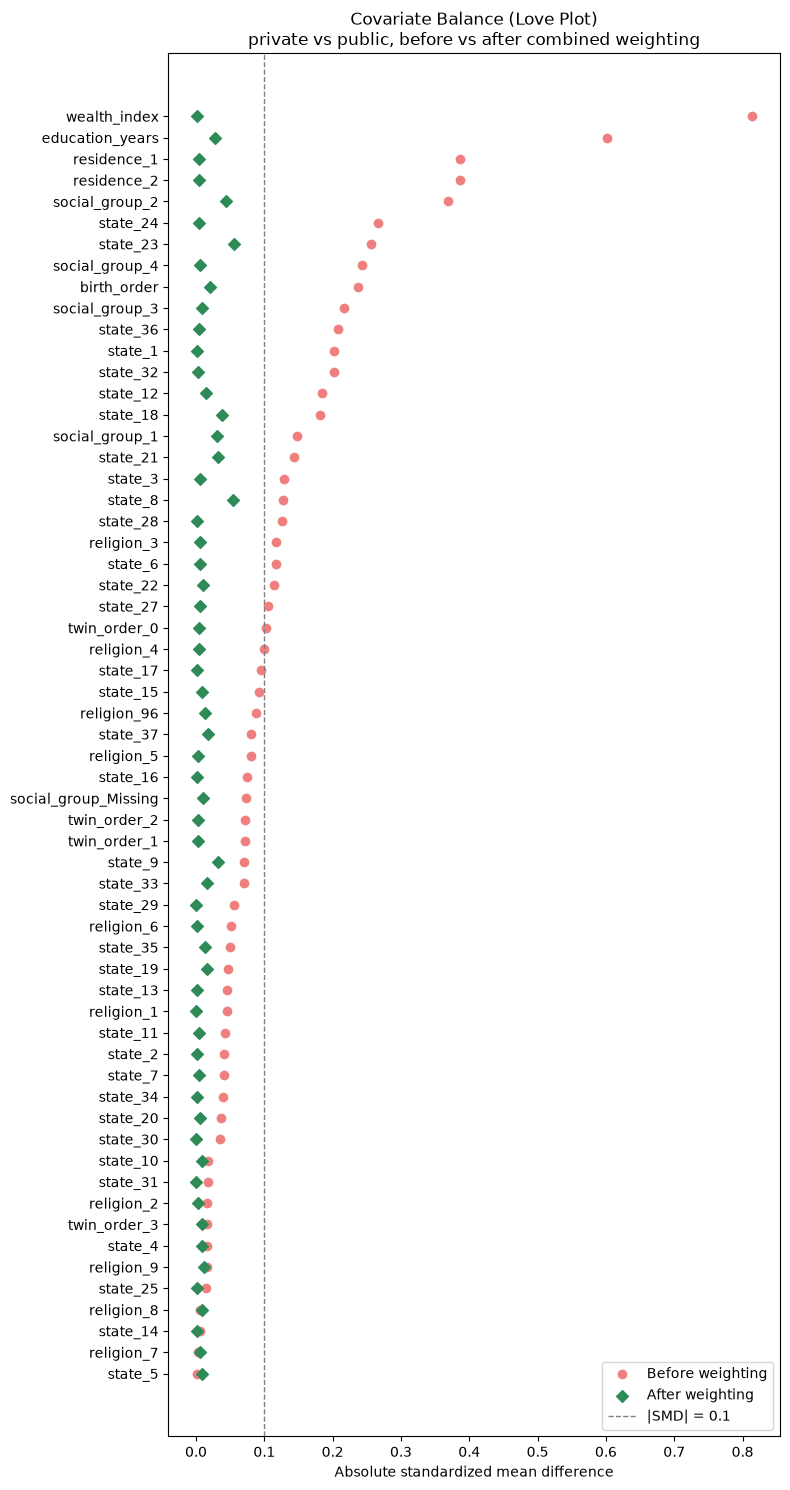

Saved: ..\..\outputs\figures\b4_love_plot.png


In [28]:
love_data = covariate_balance.sort_values("smd_before", key=np.abs)
fig, ax = plt.subplots(figsize=(8, max(6, len(love_data) * 0.25)))
y_pos = np.arange(len(love_data))
ax.scatter(love_data["smd_before"].abs(), y_pos, label="Before weighting", color="lightcoral", marker="o")
ax.scatter(love_data["smd_after"].abs(), y_pos, label="After weighting", color="seagreen", marker="D")
ax.axvline(SMD_FLAG_THRESHOLD, color="gray", linestyle="--", linewidth=1, label=f"|SMD| = {SMD_FLAG_THRESHOLD}")
ax.set_yticks(y_pos)
ax.set_yticklabels(love_data["covariate"])
ax.set_xlabel("Absolute standardized mean difference")
ax.set_title("Covariate Balance (Love Plot)\nprivate vs public, before vs after combined weighting")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b4_love_plot.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b4_love_plot.png")

## 11. Save row-level diagnostics and metadata

In [29]:
diagnostics.to_csv(TABLES_DIR / "b4_row_level_propensity_diagnostics.csv", index=False)
print(f"Saved row-level diagnostics: {diagnostics.shape}")

Saved row-level diagnostics: (200794, 10)


In [30]:
metadata = {
    "random_state": RANDOM_STATE,
    "population": {
        "n_total_v2": n_loaded,
        "n_excluded_other": int(n_other),
        "n_analytic_sample": int(len(analytic)),
    },
    "exposure": {"private": 1, "public": 0},
    "confounder_set": {
        "included": confounder_cols,
        "excluded_with_reasons": {
            "ANC/service mediators (all)": "post-exposure health-service mediators, per Step 2 domain reclassification",
            "facility_type / delivery_place_code": "the exposure itself, not a confounder",
            "maternal_age": "sensitivity-only -- v012 is age at interview, not verified as age at the analyzed birth; not safely derivable as age-at-index-birth from current v2 fields (would need DHS b3/v011 CMC dates, not in v2). age_at_first_birth is exact for birth_order==1 records only.",
            "bmi": "sensitivity-only -- pre-exposure timing relative to the analyzed birth not verified",
            "health_insurance": "sensitivity-only -- pre-exposure timing/uptake relative to facility choice not verified",
            "convulsions_during_pregnancy / swelling_during_pregnancy": "sensitivity-only -- systematic/non-random missingness (Step 2 audit)",
            "total_children_ever_born": "excluded -- unresolved timing TODO (survey-date snapshot) from Step 2",
            "preceding_birth_interval / age_at_first_birth": "optional sensitivity variables -- unresolved DHS special-code TODO from Step 2",
            "district": "optional sensitivity variable -- finer-grained geographic control than the primary state adjustment",
            "risk_stratum_primary / risk_stratum_refined_sensitivity / first_birth": "v2-derived stratifiers, not baseline confounders",
        },
    },
    "propensity_model": {
        "primary": "LogisticRegression(max_iter=1000, random_state=42), fit survey-weighted via sample_weight=sample_weight_normalized, no class rebalancing, no outcome-based tuning",
        "ml_sensitivity_model_run": RUN_ML_SENSITIVITY_MODEL,
        "ml_sensitivity_model_survey_weighted": False,
    },
    "clipping": {"method": "hard clip", "epsilon": CLIP_EPS},
    "trimming_sensitivity_thresholds": {"lower": TRIM_LOWER, "upper": TRIM_UPPER},
    "weighting": {
        "stabilized_ipw_formula": "private: P(private)/e ; public: (1-P(private))/(1-e); P(private) is the survey-weighted marginal prevalence; e itself now comes from a survey-weighted propensity model (Section 4)",
        "combined_weight_formula": "sample_weight_normalized * stabilized_ipw",
        "combined_weight_used_for": "post-weighting SMD and ESS diagnostics ONLY -- not used to estimate any effect in this notebook",
    },
    "smd_flag_threshold": SMD_FLAG_THRESHOLD,
    "common_support_range": [float(common_support_low), float(common_support_high)],
    "interpretation_rule": "Diagnostic only. No causal effect is estimated or implied by this notebook.",
}

with open(METADATA_DIR / "b4_propensity_overlap_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b4_propensity_overlap_metadata.json")

Saved: ..\..\outputs\metadata\b4_propensity_overlap_metadata.json
